## 1. Set up Libraries


In [1]:
# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path

<a id='Reading_data'></a>

## 2. Reading data <a href='#Top' style="text-decoration: none;">^</a><br>

In this section, raw data will be read, overviewed and checked if any cleaning is required.


In [5]:
DATA_DIR = Path("../data/final")
ENCODED_FILE = DATA_DIR / "encoded_unsupervised.csv"
TARGET_COL = "final_result"

# Load the dataset
df = pd.read_csv(ENCODED_FILE)

# Shape of the dataset before removing target column
print(f"Dataset shape before removing target column: {df.shape}")

# Ensure the target column exists
if TARGET_COL in df.columns:
    df.drop(columns=[TARGET_COL], inplace=True)
    print(f"Target column '{TARGET_COL}' removed.")
    print(f"Dataset shape after removing target column: {df.shape}")
else:
    print(f"Target column '{TARGET_COL}' not found in dataset.")

Dataset shape before removing target column: (32548, 25)
Target column 'final_result' not found in dataset.


In [6]:
# Check for missing values and remove them (if any)
df.isnull().sum()

highest_education             0
imd_band                      0
age_band                      0
num_of_prev_attempts          0
studied_credits               0
date_registration             0
avg_clicks_per_day            0
module_presentation_length    0
tma_cma_weighted_score        0
total_submissions             0
late_submissions_count        0
avg_submission_delay          0
sites_revisit_ratio           0
activity_diversity_ratio      0
code_module_BBB               0
code_module_CCC               0
code_module_DDD               0
code_module_EEE               0
code_module_FFF               0
code_module_GGG               0
code_presentation_2013J       0
code_presentation_2014B       0
code_presentation_2014J       0
gender_M                      0
disability_Y                  0
dtype: int64

In [7]:
from sklearn.preprocessing import StandardScaler

# === Feature Engineering ===
eps = 1e-6  # prevents divide-by-zero

# 1) Late submission ratio (time-management discipline)
df['late_submission_ratio'] = df['late_submissions_count'] / (df['total_submissions'] + eps)

# 2) Procrastination index (severity of late behaviour)
df['procrastination_index'] = (
    df['late_submission_ratio'] * df['avg_submission_delay'].clip(lower=0)
)

# 3) Score per submission (efficiency of attempts)
df['score_per_submission'] = df['tma_cma_weighted_score'] / (df['total_submissions'] + eps)

# 4) Effort-to-score ratio (hard-working vs efficient learners)
df['effort_to_score_ratio'] = df['avg_clicks_per_day'] / (df['tma_cma_weighted_score'] + 1)

print("New features created:")
print(df[['late_submission_ratio', 'procrastination_index', 'score_per_submission', 'effort_to_score_ratio']].describe())

# === Select Final 9 Columns ===
# 5 existing (already scaled) + 4 new (need scaling)
existing_features = [
    'avg_clicks_per_day',
    'activity_diversity_ratio',
    'sites_revisit_ratio',
    'total_submissions',
    'avg_submission_delay'
]

new_features = [
    'late_submission_ratio',
    'procrastination_index',
    'score_per_submission',
    'effort_to_score_ratio'
]

# === Scale New Features Only ===
scaler_new = StandardScaler()
df[new_features] = scaler_new.fit_transform(df[new_features])

print("\nNew features after scaling:")
print(df[new_features].describe())

# === Keep Only Final 9 Columns ===
final_features = existing_features + new_features
df = df[final_features]

print(f"\nFinal dataset shape: {df.shape}")
print(f"Final columns: {df.columns.tolist()}")

New features created:
       late_submission_ratio  procrastination_index  score_per_submission  \
count           3.254800e+04           3.254800e+04          32548.000000   
mean            3.953741e+03           1.915362e+04          47749.266204   
std             2.548643e+05           2.620120e+05         168494.132519   
min            -8.283661e+05          -1.993858e+02             -7.977664   
25%            -8.417284e-01           0.000000e+00             -0.004000   
50%             1.325388e+00           0.000000e+00             -0.000000   
75%             2.390034e+00           0.000000e+00              1.114284   
max             1.584907e+06           3.302955e+07         973000.000000   

       effort_to_score_ratio  
count           32548.000000  
mean               -0.047759  
std                 0.725330  
min                -1.484743  
25%                -0.343565  
50%                 0.000010  
75%                 0.353685  
max                11.718226  

New 

In [8]:
all_features = df.copy()
print(f"\nShape of all features: {all_features.shape}")

# # Taking features only for engagement
# engagement = all_features[['avg_clicks_per_day', 'total_submissions', 'sites_revisit_ratio', 'activity_diversity_ratio', 'studied_credits']].copy()
# print(f"\nShape of engagement features: {engagement.shape}")

# # Taking behavioral features only
# behavioral = all_features[['num_of_prev_attempts', 'date_registration', 'tma_cma_weighted_score', 'late_submissions_count', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG']].copy()
# print(f"\nShape of behavioral features: {behavioral.shape}")



Shape of all features: (32548, 9)


<a id='DBSCAN'></a>

### 3.2 DBSCAN<a href='#Top' style="text-decoration: none;">^</a><br>

This chapter describes how DBSCAN (Density-Based Spatial Clustering of Applications with Noise) works and shows its implementation to the mall customers segmentation.


In [10]:
from sklearn.cluster import DBSCAN

In [ ]:
from itertools import product

eps_values = np.arange(0.5,2.5,0.2) # eps values to be investigated
min_samples = np.arange(15, 46, 15) # min_samples values to be investigated

DBSCAN_params = list(product(eps_values, min_samples))

In [40]:
from sklearn.metrics import silhouette_score
import time

no_of_clusters = []
sil_score = []
start_time = time.time()

for i, p in enumerate(DBSCAN_params):
    iter_start = time.time()
    DBS_clustering = DBSCAN(eps=p[0], min_samples=p[1]).fit(all_features)
    n_clusters = len(np.unique(DBS_clustering.labels_))
    no_of_clusters.append(n_clusters)
    
    # Silhouette score requires at least 2 clusters (excluding noise-only results)
    n_labels_no_noise = len(set(DBS_clustering.labels_)) - (1 if -1 in DBS_clustering.labels_ else 0)
    if n_labels_no_noise >= 2:
        sil_score.append(silhouette_score(all_features, DBS_clustering.labels_))
    else:
        sil_score.append(-1)  # Invalid score placeholder
    
    
    iter_time = time.time() - iter_start
    print(f"✓ Iteration {i+1}/{len(DBSCAN_params)} (eps={p[0]:.1f}, min_samples={p[1]}): {iter_time:.1f}s")

total_time = time.time() - start_time
print(f"\n✓ Total time: {total_time:.1f}s ({total_time/60:.1f} minutes)")

✓ Iteration 1/20 (eps=0.5, min_samples=15): 19.9s
✓ Iteration 2/20 (eps=0.5, min_samples=30): 17.5s
✓ Iteration 3/20 (eps=0.7, min_samples=15): 18.8s
✓ Iteration 4/20 (eps=0.7, min_samples=30): 18.6s
✓ Iteration 5/20 (eps=0.9, min_samples=15): 21.0s
✓ Iteration 6/20 (eps=0.9, min_samples=30): 20.6s
✓ Iteration 7/20 (eps=1.1, min_samples=15): 19.4s
✓ Iteration 8/20 (eps=1.1, min_samples=30): 18.4s
✓ Iteration 9/20 (eps=1.3, min_samples=15): 22.1s
✓ Iteration 10/20 (eps=1.3, min_samples=30): 21.2s
✓ Iteration 11/20 (eps=1.5, min_samples=15): 24.6s
✓ Iteration 12/20 (eps=1.5, min_samples=30): 29.0s
✓ Iteration 13/20 (eps=1.7, min_samples=15): 28.0s
✓ Iteration 14/20 (eps=1.7, min_samples=30): 28.2s
✓ Iteration 15/20 (eps=1.9, min_samples=15): 31.7s
✓ Iteration 16/20 (eps=1.9, min_samples=30): 31.6s
✓ Iteration 17/20 (eps=2.1, min_samples=15): 36.0s
✓ Iteration 18/20 (eps=2.1, min_samples=30): 35.9s
✓ Iteration 19/20 (eps=2.3, min_samples=15): 39.1s
✓ Iteration 20/20 (eps=2.3, min_samples=

A heatplot below shows how many clusters were generated by the DBSCAN algorithm for the respective parameters combinations.


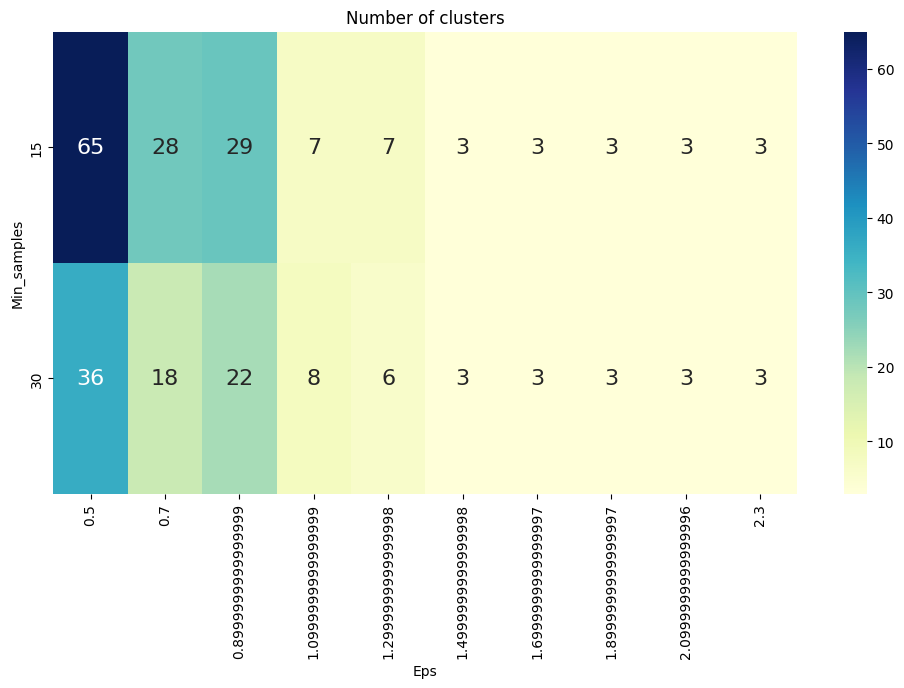

In [41]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['No_of_clusters'] = no_of_clusters

pivot_1 = pd.pivot_table(tmp, values='No_of_clusters', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot_1, annot=True,annot_kws={"size": 16}, cmap="YlGnBu", ax=ax)
ax.set_title('Number of clusters')
plt.show()

\The heatplot above shows, the number of clusters vary from 22 to 8. However, most of the combinations gives 10-12 clusters.
To decide which combination to choose I will use a metric - a silhuette score and I will plot it as a heatmap again.


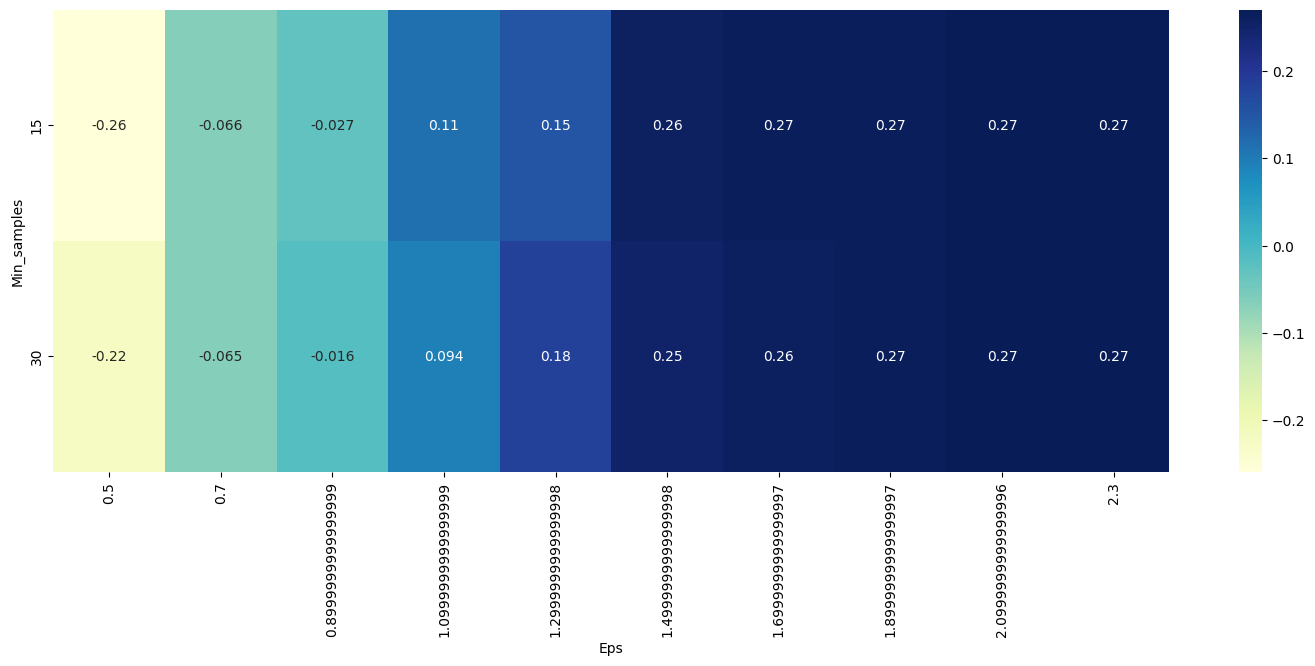

In [42]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['Sil_score'] = sil_score

pivot_1 = pd.pivot_table(tmp, values='Sil_score', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_1, annot=True, annot_kws={"size": 10}, cmap="YlGnBu", ax=ax)
plt.show()

In [11]:
DBS_clustering = DBSCAN(eps=2, min_samples=30).fit(all_features)

DBSCAN_clustered = all_features.copy()
DBSCAN_clustered.loc[:,'Cluster'] = DBS_clustering.labels_ # append labels to points

PCA explained variance ratio: [0.80735137 0.0685184 ]
Total variance explained: 87.59%


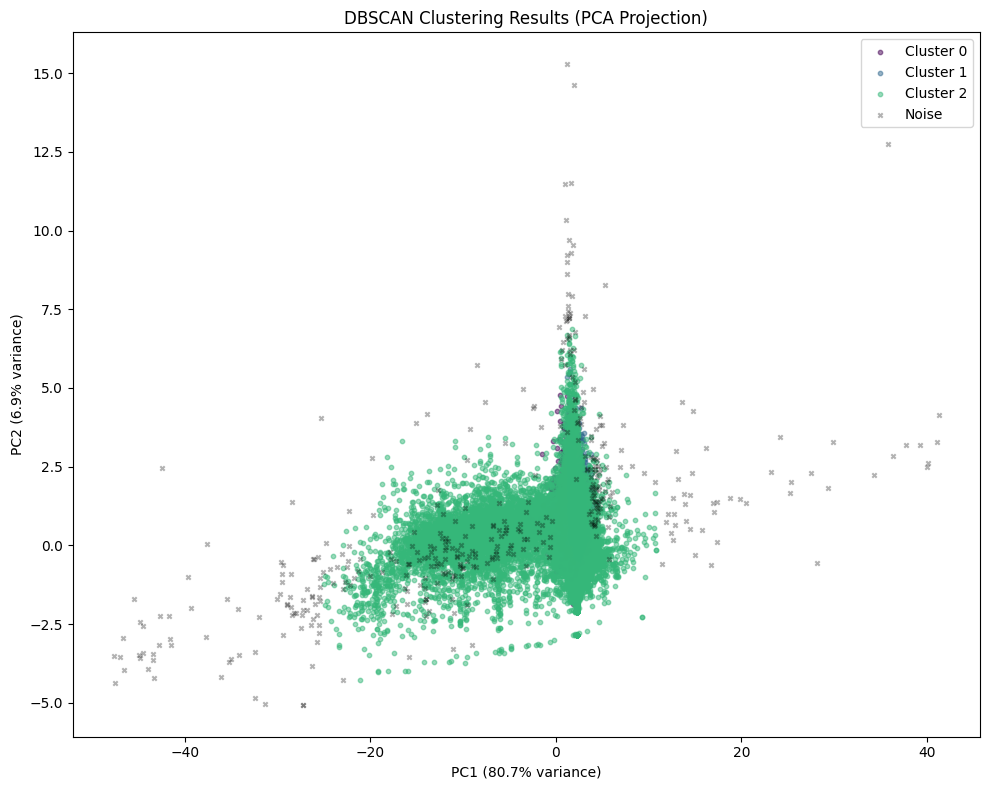


Noise points: 401 (1.2%)


In [12]:
# Reduce to 2D using PCA
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
df_pca = pca.fit_transform(all_features)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Plot DBSCAN clusters
plt.figure(figsize=(10, 8))

# Handle noise points (label = -1) separately
unique_labels = set(DBS_clustering.labels_)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Noise points in black
        color = 'black'
        marker = 'x'
        alpha = 0.3
        label_name = 'Noise'
    else:
        marker = 'o'
        alpha = 0.5
        label_name = f'Cluster {label}'
    
    mask = DBS_clustering.labels_ == label
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1], 
                c=[color], marker=marker, alpha=alpha, s=10, label=label_name)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('DBSCAN Clustering Results (PCA Projection)')
plt.legend()
plt.tight_layout()
plt.show()

# Print noise statistics
n_noise = (DBS_clustering.labels_ == -1).sum()
print(f"\nNoise points: {n_noise} ({n_noise/len(DBS_clustering.labels_):.1%})")
